# Temporal Mamba Experiment Diagnostics

This notebook mirrors the `exp/scripts/run_temporal_mamba.sh` -> `exp/run_temporal.py` experiment path, but breaks the run into readable stages and adds diagnostics for the dataset, model, configuration, and train/validation/test behavior.

In [1]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'exp').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'exp').exists(), 'Run this notebook from the repo root or notebooks/.'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.parser import get_parser
from exp.temporal_benchmark_utils import (
    _env_int,
    advance_context as _advance_context,
    build_supervised_snapshots as _build_supervised_snapshots,
    estimate_time_window_grid as _estimate_time_window_grid,
    evaluate_model_streaming as _evaluate_model_streaming,
    load_temporal_data as _load_temporal_data,
    make_model as _make_model,
    make_node_features as _make_node_features,
    make_static_edge_index as _make_static_edge_index,
    make_window_candidates as _make_window_candidates,
    recommend_time_window as _recommend_time_window,
    run_epoch as _run_epoch,
    split_edge_ids as _split_edge_ids,
    summarize_supervision as _summarize_supervision,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
torch.set_printoptions(sci_mode=False)


/home/zhuowez1/miniconda3/envs/nsd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Hyperparam Knobs 

In [ ]:
# Main notebook knobs.
DATASET_NAME = 'tgbn-trade'  # Also supports 'tgbl-wiki-v2', 'tgbl-review-v2', 'tkgl-smallpedia', 'thgl-software'. 'tgbn-trade'
INCLUDE_STATIC_CONTEXT = True  # Used for datasets that expose static edges, such as tkgl-smallpedia.

# Set SNAPSHOT_TIME_WINDOW to None for one snapshot per exact timestamp,
# or to a positive integer to merge nearby timestamps into one snapshot.
# If AUTO_PICK_SNAPSHOT_TIME_WINDOW is True, the notebook may overwrite this value
# with a recommendation from the estimator below.
SNAPSHOT_TIME_WINDOW = None

# Snapshot tuning interface.
SNAPSHOT_TUNING_SPLIT = 'train'
SNAPSHOT_WINDOW_CANDIDATES = None  # Example: [None, 1, 2, 5, 10, 20, 50, 100]
SNAPSHOT_TARGET_MAX_SNAPSHOTS = 250
SNAPSHOT_TARGET_MAX_MEAN_EDGES = 256
AUTO_PICK_SNAPSHOT_TIME_WINDOW = True
TEMPORAL_BPTT_STEPS = None  # Set to None to train on the full snapshot sequence at once.
TEMPORAL_EPOCH_PROGRESS_BAR = True
TEMPORAL_EVAL_EVERY = 2  # Evaluate every N epochs during temporal training, in addition to the final evaluation.
TEMPORAL_SKIP_TRAIN_EVAL = False
TEMPORAL_EPOCHS = 50

parser = get_parser()
args = parser.parse_args([
    f'--dataset={DATASET_NAME}',
    f'--temporal_dataset={DATASET_NAME}',
    '--model=TemporalMambaSheaf',
    '--stateful_temporal=True',
    '--closure_hops=1',
    f'--temporal_epochs={TEMPORAL_EPOCHS}',
    '--temporal_train_edges=2048',
    '--temporal_val_edges=256',
    '--temporal_test_edges=256',
])

args.temporal_snapshot_time_window = SNAPSHOT_TIME_WINDOW
args.temporal_bptt_steps = TEMPORAL_BPTT_STEPS
args.temporal_epoch_progress_bar = TEMPORAL_EPOCH_PROGRESS_BAR
args.temporal_eval_every = TEMPORAL_EVAL_EVERY
args.temporal_skip_train_eval = TEMPORAL_SKIP_TRAIN_EVAL

device = torch.device(f'cuda:{args.cuda}' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(args.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)

config_df = pd.DataFrame([
    {'field': 'dataset_name_requested', 'value': DATASET_NAME},
    {'field': 'include_static_context', 'value': INCLUDE_STATIC_CONTEXT},
    {'field': 'device', 'value': str(device)},
    {'field': 'seed', 'value': args.seed},
    {'field': 'lr', 'value': args.lr},
    {'field': 'weight_decay', 'value': args.weight_decay},
    {'field': 'temporal_epochs', 'value': args.temporal_epochs},
    {'field': 'temporal_train_edges', 'value': args.temporal_train_edges},
    {'field': 'temporal_val_edges', 'value': args.temporal_val_edges},
    {'field': 'temporal_test_edges', 'value': args.temporal_test_edges},
    {'field': 'temporal_max_edges_per_snapshot', 'value': args.temporal_max_edges_per_snapshot},
    {'field': 'temporal_snapshot_time_window', 'value': args.temporal_snapshot_time_window},
    {'field': 'temporal_bptt_steps', 'value': args.temporal_bptt_steps},
    {'field': 'temporal_epoch_progress_bar', 'value': args.temporal_epoch_progress_bar},
    {'field': 'temporal_eval_every', 'value': args.temporal_eval_every},
    {'field': 'temporal_skip_train_eval', 'value': args.temporal_skip_train_eval},
])
display(config_df)


,field,value
0,dataset_name_requested,tgbl-wiki-v2
1,include_static_context,True
2,device,cuda:0
3,seed,43
4,lr,0.01
5,weight_decay,0.0005
6,temporal_epochs,50
7,temporal_train_edges,2048
8,temporal_val_edges,256
9,temporal_test_edges,256


## 1. Prepare the temporal dataset and inspect metadata

In [3]:
dataset_requested_name = args.temporal_dataset
dataset_spec, dataset, temporal_data = _load_temporal_data(dataset_requested_name)
dataset_name = dataset_spec.loader_name
num_nodes = int(dataset.num_nodes)
output_dim = int(getattr(dataset, 'num_classes', num_nodes))
node_features = _make_node_features(dataset, num_nodes).to(device)
static_edge_index = _make_static_edge_index(dataset) if INCLUDE_STATIC_CONTEXT else None

total_edges = int(len(temporal_data.src))
train_edge_ids, val_edge_ids, test_edge_ids, split_source = _split_edge_ids(dataset, temporal_data)
split_edge_map = {
    'train': train_edge_ids,
    'val': val_edge_ids,
    'test': test_edge_ids,
}
split_edge_caps = {
    'train': args.temporal_train_edges,
    'val': args.temporal_val_edges,
    'test': args.temporal_test_edges,
}

if SNAPSHOT_TUNING_SPLIT not in split_edge_map:
    raise ValueError(f'SNAPSHOT_TUNING_SPLIT must be one of {sorted(split_edge_map)}')

candidate_windows = _make_window_candidates(
    temporal_data.t,
    split_edge_map[SNAPSHOT_TUNING_SPLIT],
    manual_candidates=SNAPSHOT_WINDOW_CANDIDATES,
)
snapshot_window_estimates = _estimate_time_window_grid(
    dataset_spec,
    dataset,
    temporal_data,
    split_edge_map[SNAPSHOT_TUNING_SPLIT],
    split_edge_caps[SNAPSHOT_TUNING_SPLIT],
    candidate_windows,
)
snapshot_window_recommendation = _recommend_time_window(
    snapshot_window_estimates,
    target_max_snapshots=SNAPSHOT_TARGET_MAX_SNAPSHOTS,
    target_max_mean_edges=SNAPSHOT_TARGET_MAX_MEAN_EDGES,
)

intro_lines = [
    f'**Requested dataset:** `{dataset_requested_name}`',
    f'**Loader dataset:** `{dataset_name}`',
    f'**Task family:** `{dataset_spec.task_family}`',
    f'**Split source:** `{split_source}`',
    f'**Snapshot tuning split:** `{SNAPSHOT_TUNING_SPLIT}` with initial edge cap `{split_edge_caps[SNAPSHOT_TUNING_SPLIT]}`.',
    'The table below is a cheap estimate based on timestamps and split supervision only; it does not build full snapshot objects yet.',
]
display(Markdown('  \\n'.join(intro_lines)))
if dataset_spec.notes:
    display(Markdown(f'**Task note:** {dataset_spec.notes}'))

display(snapshot_window_estimates[[
    'window_label',
    'edge_prefix',
    'estimated_snapshots',
    'estimated_mean_edges',
    'estimated_max_edges',
    'compression_ratio',
    'has_label_supervision',
    'first_label_timestamp',
]])

if snapshot_window_recommendation is not None:
    display(Markdown(
        f"**Recommended `SNAPSHOT_TIME_WINDOW`:** `{snapshot_window_recommendation['window_label']}` "
        f"for about **{int(snapshot_window_recommendation['estimated_snapshots'])}** estimated snapshots "
        f"and **{snapshot_window_recommendation['estimated_mean_edges']:.1f}** mean edges per snapshot."
    ))
elif not snapshot_window_estimates.empty:
    fallback_row = snapshot_window_estimates.sort_values(['estimated_snapshots', 'estimated_mean_edges']).iloc[0]
    display(Markdown(
        f"**No candidate met the current targets.** Smallest estimated snapshot count in the sweep is "
        f"**{int(fallback_row['estimated_snapshots'])}** at window `{fallback_row['window_label']}`."
    ))

if AUTO_PICK_SNAPSHOT_TIME_WINDOW and snapshot_window_recommendation is not None:
    args.temporal_snapshot_time_window = snapshot_window_recommendation['time_window']
    display(Markdown(
        f"**Auto-pick enabled:** using `temporal_snapshot_time_window={snapshot_window_recommendation['window_label']}` for the actual snapshot build."
    ))
else:
    display(Markdown(
        f"**Using `temporal_snapshot_time_window`:** `{('exact timestamps' if args.temporal_snapshot_time_window is None else args.temporal_snapshot_time_window)}`"
    ))

train_snapshots, train_edge_ids = _build_supervised_snapshots(
    dataset_spec,
    dataset,
    temporal_data,
    train_edge_ids,
    node_features,
    args.temporal_max_edges_per_snapshot,
    args.temporal_snapshot_time_window,
    split_name='train',
    static_edge_index=static_edge_index,
)
val_snapshots, val_edge_ids = _build_supervised_snapshots(
    dataset_spec,
    dataset,
    temporal_data,
    val_edge_ids,
    node_features,
    args.temporal_max_edges_per_snapshot,
    args.temporal_snapshot_time_window,
    split_name='validation',
    static_edge_index=static_edge_index,
)
test_snapshots, test_edge_ids = _build_supervised_snapshots(
    dataset_spec,
    dataset,
    temporal_data,
    test_edge_ids,
    node_features,
    args.temporal_max_edges_per_snapshot,
    args.temporal_snapshot_time_window,
    split_name='test',
    static_edge_index=static_edge_index,
)

assert train_snapshots and val_snapshots, 'Temporal dataset did not produce non-empty train/validation snapshot sequences.'

node_type = getattr(dataset, 'node_type', None)
edge_type = getattr(temporal_data, 'edge_type', None)
num_rels = getattr(dataset, 'num_rels', None)
dataset_metadata = {
    'dataset_requested_name': dataset_requested_name,
    'dataset_loader_name': dataset_name,
    'task_family': dataset_spec.task_family,
    'eval_metric': getattr(dataset, 'eval_metric', dataset_spec.metric_name),
    'num_nodes': num_nodes,
    'num_edges_total': total_edges,
    'output_dim': output_dim,
    'num_classes': int(getattr(dataset, 'num_classes', output_dim)) if hasattr(dataset, 'num_classes') else output_dim,
    'num_relations': int(num_rels) if num_rels is not None else 0,
    'edge_type_present': bool(edge_type is not None),
    'node_type_present': bool(node_type is not None),
    'static_edges_included': bool(static_edge_index is not None),
    'static_edge_count': int(static_edge_index.size(1) // 2) if static_edge_index is not None else 0,
    'split_source': split_source,
    'train_edges_selected': int(train_edge_ids.numel()),
    'val_edges_selected': int(val_edge_ids.numel()),
    'test_edges_selected': int(test_edge_ids.numel()),
    'timestamp_min': int(temporal_data.t.min().item()),
    'timestamp_max': int(temporal_data.t.max().item()),
    'timestamp_span': int((temporal_data.t.max() - temporal_data.t.min()).item()),
    'node_feature_shape': tuple(node_features.shape),
    'node_feature_dtype': str(node_features.dtype),
    'node_feature_device': str(node_features.device),
    'snapshot_time_window': args.temporal_snapshot_time_window,
    'snapshot_grouping': 'exact timestamps' if args.temporal_snapshot_time_window is None else f'window={args.temporal_snapshot_time_window}',
    'snapshot_tuning_split': SNAPSHOT_TUNING_SPLIT,
    'snapshot_target_max_snapshots': SNAPSHOT_TARGET_MAX_SNAPSHOTS,
    'snapshot_target_max_mean_edges': SNAPSHOT_TARGET_MAX_MEAN_EDGES,
}
display(pd.DataFrame(dataset_metadata.items(), columns=['field', 'value']))


RuntimeError: zero-dimensional tensor (at position 0) cannot be concatenated

In [ ]:
def summarize_snapshots(split_name, snapshots, edge_ids):
    supervision = _summarize_supervision(dataset_spec, dataset, snapshots)
    active_counts = [int(snapshot.active_nodes.numel()) for snapshot in snapshots]
    edge_counts = [int(snapshot.src.numel()) for snapshot in snapshots]
    timestamps = [int(snapshot.timestamp.item()) for snapshot in snapshots]
    selected_ts = temporal_data.t[edge_ids]
    raw_unique_timestamps = int(torch.unique(selected_ts).numel()) if edge_ids.numel() > 0 else 0

    edge_type_values = []
    for snapshot in snapshots:
        if snapshot.edge_types is not None:
            edge_type_values.append(snapshot.edge_types)
    unique_edge_types = int(torch.unique(torch.cat(edge_type_values)).numel()) if edge_type_values else 0

    row = {
        'split': split_name,
        'edge_ids_used': int(edge_ids.numel()),
        'raw_unique_timestamps': raw_unique_timestamps,
        'snapshots': len(snapshots),
        'compression_ratio': (len(snapshots) / raw_unique_timestamps) if raw_unique_timestamps else float('nan'),
        'edges_per_snapshot_mean': float(np.mean(edge_counts)) if edge_counts else float('nan'),
        'edges_per_snapshot_max': int(max(edge_counts)) if edge_counts else 0,
        'active_nodes_mean': float(np.mean(active_counts)) if active_counts else float('nan'),
        'active_nodes_max': int(max(active_counts)) if active_counts else 0,
        'timestamp_start': min(timestamps) if timestamps else None,
        'timestamp_end': max(timestamps) if timestamps else None,
        'unique_edge_types': unique_edge_types,
    }
    row.update(supervision)
    return row

split_summary_df = pd.DataFrame([
    summarize_snapshots('train', train_snapshots, train_edge_ids),
    summarize_snapshots('val', val_snapshots, val_edge_ids),
    summarize_snapshots('test', test_snapshots, test_edge_ids),
])
display(split_summary_df)

snapshot_preview = []
for split_name, snapshots in [('train', train_snapshots), ('val', val_snapshots), ('test', test_snapshots)]:
    for snapshot_idx, snapshot in enumerate(snapshots[:5]):
        snapshot_preview.append({
            'split': split_name,
            'snapshot_idx': snapshot_idx,
            'timestamp': int(snapshot.timestamp.item()),
            'edges': int(snapshot.src.numel()),
            'active_nodes': int(snapshot.active_nodes.numel()),
            'unique_edge_types': int(torch.unique(snapshot.edge_types).numel()) if snapshot.edge_types is not None else 0,
        })
display(pd.DataFrame(snapshot_preview))


,split,edge_ids_used,raw_unique_timestamps,snapshots,compression_ratio,snapshots_with_labels,snapshot_label_coverage,edges_per_snapshot_mean,edges_per_snapshot_max,active_nodes_mean,active_nodes_max,label_rows_total,label_rows_mean,timestamp_start,timestamp_end,snapshot_ids_with_labels
0,train,337224,24,24,1.0,23,0.958333,14051.000000,17788,221.875,242,5016,218.086957,1986,2009,23
1,val,73170,4,4,1.0,4,1.000000,18292.500000,18733,213.750,214,815,203.750000,2010,2013,4
2,test,57851,3,3,1.0,3,1.000000,19283.666667,19371,228.000,228,610,203.333333,2014,2016,3


,split,snapshot_idx,timestamp,edges,active_nodes
0,train,0,1986,9471,206
1,train,1,1987,9330,205
2,train,2,1988,9712,207
3,train,3,1989,9860,205
4,train,4,1990,9660,206
5,val,0,2010,17898,214
6,val,1,2011,18045,213
7,val,2,2012,18494,214
8,val,3,2013,18733,214
9,test,0,2014,19273,228


## 2. Instantiate the model and summarize architecture + effective training config

In [ ]:
model = _make_model(train_snapshots[0].edge_index, node_features, num_nodes, output_dim, device, args)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

effective_model_args = {
    'task_family': dataset_spec.task_family,
    'd': _env_int('TGB_SHEAF_D', 2),
    'layers': _env_int('TGB_LAYERS', 2),
    'hidden_channels': _env_int('TGB_HIDDEN_CHANNELS', 8),
    'dropout': float(os.environ.get('TGB_DROPOUT', 0.0)),
    'temporal_d_model': args.temporal_d_model or _env_int('TGB_TEMPORAL_D_MODEL', 64),
    'input_dim': int(node_features.size(1)),
    'output_dim': int(output_dim),
    'graph_size': int(num_nodes),
    'stateful_temporal': bool(args.stateful_temporal),
    'closure_hops': int(args.closure_hops),
    'normalised': True,
    'deg_normalised': False,
    'left_weights': True,
    'right_weights': True,
    'orth': 'householder',
    'edge_weights': False,
}

model_config_df = pd.DataFrame(effective_model_args.items(), columns=['field', 'value'])
display(model_config_df)

param_rows = []
total_params = 0
trainable_params = 0
for name, param in model.named_parameters():
    count = int(param.numel())
    total_params += count
    if param.requires_grad:
        trainable_params += count
    param_rows.append({
        'name': name,
        'shape': tuple(param.shape),
        'count': count,
        'trainable': bool(param.requires_grad),
    })

param_df = pd.DataFrame(param_rows).sort_values(['count', 'name'], ascending=[False, True]).reset_index(drop=True)
display(pd.DataFrame([
    {'field': 'total_params', 'value': total_params},
    {'field': 'trainable_params', 'value': trainable_params},
    {'field': 'optimizer', 'value': type(optimizer).__name__},
    {'field': 'optimizer_lr', 'value': optimizer.param_groups[0]['lr']},
    {'field': 'optimizer_weight_decay', 'value': optimizer.param_groups[0]['weight_decay']},
]))
display(param_df.head(15))


,field,value
0,d,2
1,layers,2
2,hidden_channels,8
3,dropout,0.0
4,temporal_d_model,64
5,input_dim,64
6,output_dim,255
7,graph_size,255
8,stateful_temporal,True
9,closure_hops,1


,field,value
0,total_params,52353
1,trainable_params,52353
2,optimizer,Adam
3,optimizer_lr,0.01
4,optimizer_weight_decay,0.0005


,name,shape,count,trainable
0,nodewise_learner.sequence_model.impl.in_proj.weight,"(256, 64)",16384,True
1,nodewise_learner.sequence_model.impl.out_proj.weight,"(64, 128)",8192,True
2,nodewise_learner.sequence_model.impl.x_proj.weight,"(36, 128)",4608,True
3,nodewise_learner.sequence_model.input_proj.weight,"(64, 64)",4096,True
4,nodewise_learner.sequence_model.output_proj.weight,"(64, 64)",4096,True
5,lin2.weight,"(255, 16)",4080,True
6,nodewise_learner.input_proj.weight,"(64, 50)",3200,True
7,nodewise_learner.sequence_model.impl.A_log,"(128, 16)",2048,True
8,lin1.weight,"(16, 64)",1024,True
9,nodewise_learner.memory_proj.weight,"(64, 16)",1024,True


MambaSheafDiffusion(
  (lin_right_weights): ModuleList(
    (0-1): 2 x Linear(in_features=8, out_features=8, bias=False)
  )
  (lin_left_weights): ModuleList(
    (0-1): 2 x Linear(in_features=2, out_features=2, bias=False)
  )
  (batch_norms): ModuleList()
  (sheaf_learners): ModuleList(
    (0-1): 2 x LocalConcatSheafLearner(
      (linear1): Linear(in_features=32, out_features=1, bias=False)
    )
  )
  (weight_learners): ModuleList()
  (laplacian_builder): NormConnectionLaplacianBuilder(
    (orth_transform): Orthogonal()
  )
  (epsilons): ParameterList(
      (0): Parameter containing: [torch.float32 of size 2x1 (cuda:0)]
      (1): Parameter containing: [torch.float32 of size 2x1 (cuda:0)]
  )
  (lin1): Linear(in_features=64, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=255, bias=True)
  (nodewise_learner): NodewiseMambaLearner(
    (memory_proj): Linear(in_features=16, out_features=64, bias=True)
    (input_proj): Linear(in_features=50, out_features=

## 3. Train the model and log train/validation/test behavior

In [ ]:
metric_name = getattr(dataset, 'eval_metric', dataset_spec.metric_name)
history = []
best_val_metric = float('-inf')
best_test_metric = float('nan')
best_epoch = -1
best_state_dict = None

start = time.perf_counter()
for epoch in tqdm(range(args.temporal_epochs), desc='Temporal training'):
    model.reset_temporal_state()
    train_loss = _run_epoch(
        dataset_spec,
        model,
        optimizer,
        train_snapshots,
        dataset,
        bptt_steps=args.temporal_bptt_steps,
        show_progress=args.temporal_epoch_progress_bar,
        epoch_label=f'Epoch {epoch + 1}/{args.temporal_epochs}',
        tqdm_factory=tqdm,
    )

    should_eval = ((epoch + 1) % max(args.temporal_eval_every, 1) == 0) or (epoch == args.temporal_epochs - 1)
    train_metric = float('nan')
    val_metric = float('nan')
    test_metric = float('nan')
    train_label_loss = float('nan')
    val_label_loss = float('nan')
    test_label_loss = float('nan')
    state_memory_norm = float('nan')
    state_spatial_norm = float('nan')
    val_state_memory_norm = float('nan')
    test_state_memory_norm = float('nan')

    if should_eval:
        if args.temporal_skip_train_eval:
            train_state = _advance_context(model, train_snapshots)
        else:
            train_metric, train_label_loss, train_state = _evaluate_model_streaming(
                dataset_spec,
                dataset,
                train_snapshots,
                model,
                initial_state=None,
                split_mode='train',
            )

        val_metric, val_label_loss, val_state = _evaluate_model_streaming(
            dataset_spec,
            dataset,
            val_snapshots,
            model,
            initial_state=train_state,
            split_mode='val',
        )
        test_metric, test_label_loss, test_state = _evaluate_model_streaming(
            dataset_spec,
            dataset,
            test_snapshots,
            model,
            initial_state=val_state,
            split_mode='test',
        )

        state_memory_norm = float(train_state.memory.norm().detach().cpu()) if train_state is not None and train_state.memory is not None else float('nan')
        state_spatial_norm = float(train_state.spatial.norm().detach().cpu()) if train_state is not None and train_state.spatial is not None else float('nan')
        val_state_memory_norm = float(val_state.memory.norm().detach().cpu()) if val_state is not None and val_state.memory is not None else float('nan')
        test_state_memory_norm = float(test_state.memory.norm().detach().cpu()) if test_state is not None and test_state.memory is not None else float('nan')

        if np.isfinite(val_metric) and val_metric > best_val_metric:
            best_val_metric = float(val_metric)
            best_test_metric = float(test_metric)
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'evaluated': bool(should_eval),
        f'train_{metric_name}': float(train_metric),
        f'val_{metric_name}': float(val_metric),
        f'test_{metric_name}': float(test_metric),
        'train_label_loss_eval': train_label_loss,
        'val_label_loss_eval': val_label_loss,
        'test_label_loss_eval': test_label_loss,
        'train_state_memory_norm': state_memory_norm,
        'train_state_spatial_norm': state_spatial_norm,
        'val_state_memory_norm': val_state_memory_norm,
        'test_state_memory_norm': test_state_memory_norm,
    })

elapsed = time.perf_counter() - start
history_df = pd.DataFrame(history)

summary_df = pd.DataFrame([
    {'field': f'best_val_{metric_name}', 'value': best_val_metric},
    {'field': f'best_test_{metric_name}', 'value': best_test_metric},
    {'field': 'best_epoch', 'value': best_epoch},
    {'field': 'elapsed_sec', 'value': elapsed},
    {'field': 'epochs_completed', 'value': len(history_df)},
])
display(summary_df)
display(history_df.tail(10))


Temporal training:   6%|▋         | 13/200 [00:32<06:37,  2.12s/it]

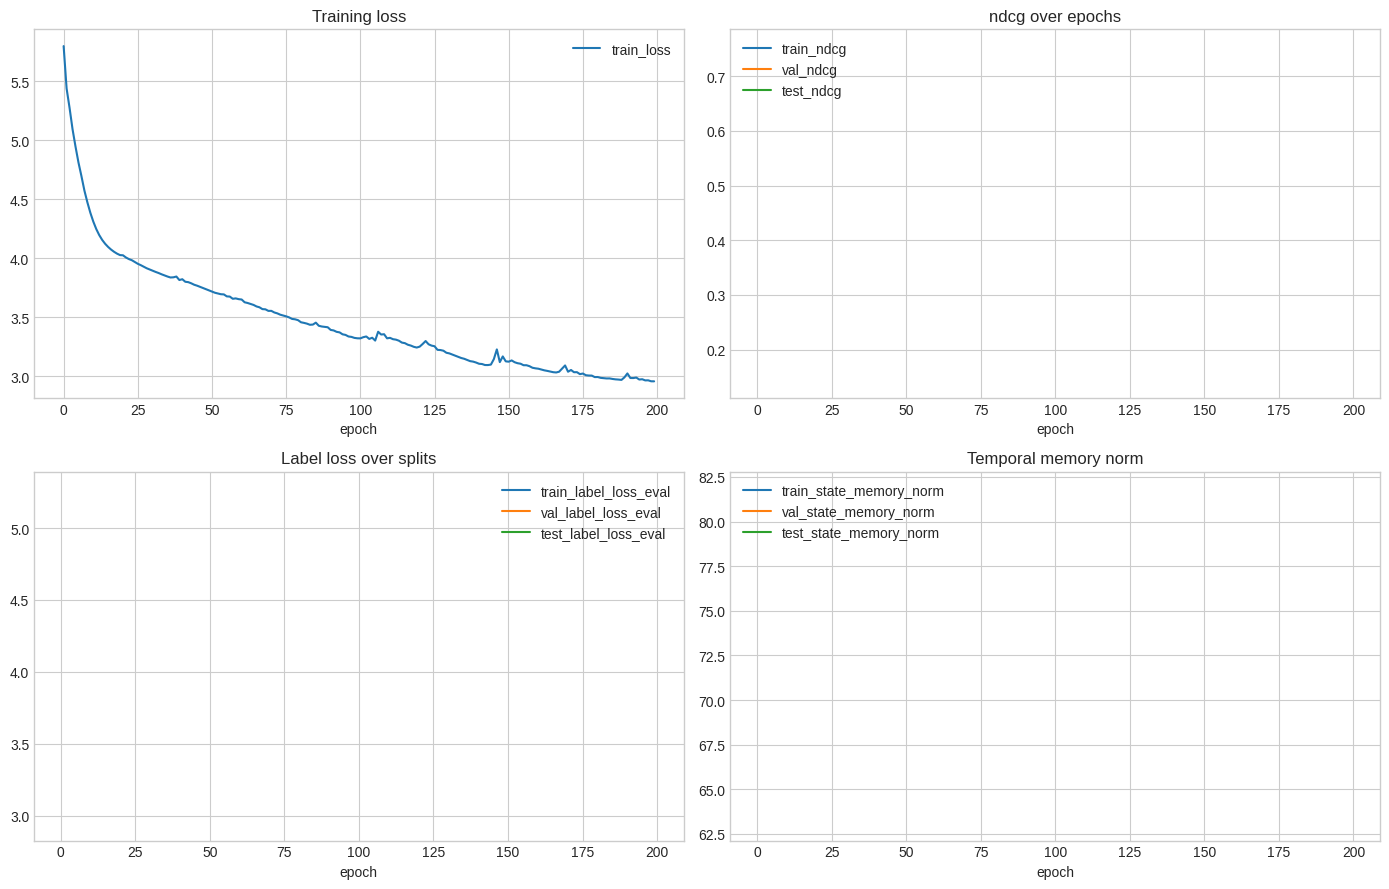

In [ ]:
eval_history_df = history_df[history_df['evaluated']] if 'evaluated' in history_df else history_df.copy()

def _plot_available(ax, df, columns, title):
    available = [col for col in columns if col in df.columns and not df[col].isna().all()]
    if available:
        df.plot(x='epoch', y=available, ax=ax, title=title)
    else:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'No evaluated data to plot yet', ha='center', va='center', transform=ax.transAxes)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

history_df.plot(x='epoch', y='train_loss', ax=axes[0, 0], title='Training loss')
_plot_available(axes[0, 1], eval_history_df, [f'train_{metric_name}', f'val_{metric_name}', f'test_{metric_name}'], f'{metric_name} over evaluated epochs')
_plot_available(axes[1, 0], eval_history_df, ['train_label_loss_eval', 'val_label_loss_eval', 'test_label_loss_eval'], 'Label loss over evaluated epochs')
_plot_available(axes[1, 1], eval_history_df, ['train_state_memory_norm', 'val_state_memory_norm', 'test_state_memory_norm'], 'Temporal memory norm')

for ax in axes.flat:
    ax.set_xlabel('epoch')

plt.tight_layout()
plt.show()


## 4. Final diagnostic summary

In [ ]:
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

model.reset_temporal_state()
if args.temporal_skip_train_eval:
    best_train_metric = float('nan')
    best_train_loss = float('nan')
    best_train_state = _advance_context(model, train_snapshots)
else:
    best_train_metric, best_train_loss, best_train_state = _evaluate_model_streaming(
        dataset_spec,
        dataset,
        train_snapshots,
        model,
        initial_state=None,
        split_mode='train',
    )

best_val_metric_stream, best_val_loss_stream, best_val_state = _evaluate_model_streaming(
    dataset_spec,
    dataset,
    val_snapshots,
    model,
    initial_state=best_train_state,
    split_mode='val',
)
best_test_metric_stream, best_test_loss_stream, best_test_state = _evaluate_model_streaming(
    dataset_spec,
    dataset,
    test_snapshots,
    model,
    initial_state=best_val_state,
    split_mode='test',
)

final_diagnostics = pd.DataFrame([
    {
        'split': 'train',
        metric_name: best_train_metric,
        'label_loss': best_train_loss,
        'num_snapshots': len(train_snapshots),
        'state_memory_norm': float(best_train_state.memory.norm().detach().cpu()) if best_train_state and best_train_state.memory is not None else float('nan'),
        'state_spatial_norm': float(best_train_state.spatial.norm().detach().cpu()) if best_train_state and best_train_state.spatial is not None else float('nan'),
    },
    {
        'split': 'val',
        metric_name: best_val_metric_stream,
        'label_loss': best_val_loss_stream,
        'num_snapshots': len(val_snapshots),
        'state_memory_norm': float(best_val_state.memory.norm().detach().cpu()) if best_val_state and best_val_state.memory is not None else float('nan'),
        'state_spatial_norm': float(best_val_state.spatial.norm().detach().cpu()) if best_val_state and best_val_state.spatial is not None else float('nan'),
    },
    {
        'split': 'test',
        metric_name: best_test_metric_stream,
        'label_loss': best_test_loss_stream,
        'num_snapshots': len(test_snapshots),
        'state_memory_norm': float(best_test_state.memory.norm().detach().cpu()) if best_test_state and best_test_state.memory is not None else float('nan'),
        'state_spatial_norm': float(best_test_state.spatial.norm().detach().cpu()) if best_test_state and best_test_state.spatial is not None else float('nan'),
    },
])
display(final_diagnostics)

display(Markdown(
    f'Best validation `{metric_name}`: **{best_val_metric:.4f}** at epoch **{best_epoch}**  '
    f'Best corresponding test `{metric_name}`: **{best_test_metric:.4f}**  '
    f'Total runtime: **{elapsed:.2f}s**'
))


,split,ndcg,label_loss,num_snapshots,state_memory_norm,state_spatial_norm
0,train,0.769463,2.958842,24,81.548378,193.483749
1,val,0.717558,2.942296,4,81.921585,194.069275
2,test,0.712237,2.962709,3,81.881508,194.023926


Best validation `ndcg`: **0.7169** at epoch **197**  Best corresponding test `ndcg`: **0.7126**  Total runtime: **618.33s**

In [ ]:
# Save the configuration and results for potential later analysis.
results_dir = REPO_ROOT / 'results' / f'{dataset_spec.loader_name}_{args.model}_{int(time.time())}'
results_dir.mkdir(parents=True, exist_ok=True)
config_df.to_csv(results_dir / 'config.csv', index=False)
model_config_df.to_csv(results_dir / 'model_config.csv', index=False)
split_summary_df.to_csv(results_dir / 'split_summary.csv', index=False)
snapshot_window_estimates.to_csv(results_dir / 'snapshot_window_estimates.csv', index=False)
summary_df.to_csv(results_dir / 'training_summary.csv', index=False)
history_df.to_csv(results_dir / 'history.csv', index=False)
final_diagnostics.to_csv(results_dir / 'final_diagnostics.csv', index=False)
